Goals: Build the base biotrove model using constrained-clustering that ensures members of the same genus cluster belong to the same family and members of the same species cluster belong to the genus cluster using pretrained (on ImageNet) ResNet101 model from PyTorch with double layer extraction.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
# Import Statements
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
from torch.cuda.amp import autocast, GradScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import umap
import shutil
import random
from tqdm import tqdm
import warnings
import glob
import seaborn as sns
import plotly.express as px
from pathlib import Path
from collections import defaultdict
from copkmeans.cop_kmeans import cop_kmeans
from sklearn.metrics import pairwise_distances_argmin_min
from collections import Counter
import multiprocessing
import time
from sklearn.decomposition import PCA

In [3]:
print(torch.cuda.is_available())

True


In [6]:
# Check gpu useage

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

print(torch.version.cuda)          # PyTorch CUDA version
print(torch.backends.cudnn.enabled) # Should be true

PyTorch version: 2.8.0+cu129
CUDA available: True
CUDA device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 4050 Laptop GPU
12.9
True


In [7]:
# GPU useage test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

x = torch.randn(1000, 1000, device=device)
y = torch.mm(x, x)
print(y.device) 

Device: cuda
cuda:0


In [8]:
# Paths to image and metadata subset

subset_img_dir = "[YOUR IMG PATH HERE]"    
subset_csv_path = "[YOUR METADATA CSV PATH HERE]"        

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load metadata

df_meta = pd.read_csv(subset_csv_path)
assert 'hash_id' in df_meta.columns, "CSV missing 'hash_id' column"
assert 'family' in df_meta.columns, "CSV missing 'family' column"

df_meta.rename(columns={'family': 'family_cluster'}, inplace=True)
print("Metadata preview:")
print(df_meta.head())

# Map images to csv filepaths
image_dir = Path(subset_img_dir)
allowed_exts = {'.jpg', '.jpeg', '.png'}

# 1) Index all images once (recursive, meaning: look into all directories and subdirectories )
all_paths = [p for p in image_dir.rglob("*") if p.suffix.lower() in allowed_exts]
print(f"Indexed {len(all_paths):,} image files")

# 2) Build stem to list(paths) mapping
# Defaultdict(list) creates an empty list for new keys and '.append' adds the object 'p' as a string in that list for every path in our list 'all_paths'
stem_to_paths = defaultdict(list)
for p in all_paths:
    stem_to_paths[p.stem].append(str(p)) # p.stem is filepath without the extension (without jpeg, jpg, or png)

# 3) Create a simple first-match dict (stem to first path)
first_match = {stem: paths[0] for stem, paths in stem_to_paths.items()}

# 4) Vectorized mapping into dataframe (fast)
df_meta['hash_id_str'] = df_meta['hash_id'].astype(str).str.strip()
df_meta['path'] = df_meta['hash_id_str'].map(first_match)  # NaN for missing

# 5) Build the same dict you had originally
df_meta_found = df_meta[df_meta['path'].notna()].reset_index(drop=True)
hashid_to_path = dict(zip(df_meta_found['hash_id_str'], df_meta_found['path']))
missing_hashids = df_meta[df_meta['path'].isna()]['hash_id_str'].tolist()

print(f"Found {len(hashid_to_path):,} matches; {len(missing_hashids):,} missing.")
if missing_hashids:
    print("Example missing ids:", missing_hashids[:5])

Using device: cuda
Metadata preview:
                    hash_id family_cluster
0  223m6ywujk3htx2s3kfqx7ee    Acanthaceae
1  2aba7w224g4tso44mtzpnizg    Acanthaceae
2  2dovrj4uex7apou4zyu7nau7    Acanthaceae
3  2f53p6wsfhsnik2sy3jxn2ok    Acanthaceae
4  2fvqsa7ldatavhuevcvia5lm    Acanthaceae
Indexed 49,633 image files
Found 49,633 matches; 0 missing.


In [9]:
# Dataset and dataloader
# Image transforms
img_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset
class HashImageDataset(Dataset):
    def __init__(self, mapping, transform=None):
        self.items = list(mapping.items())
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        hid, path = self.items[idx]
        with Image.open(path) as img:
            img = img.convert('RGB')
            if self.transform:
                img = self.transform(img)
        return hid, img

dataset = HashImageDataset(hashid_to_path, img_transform)
loader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

In [10]:
# Model

class ResNet101Intermediate(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained ResNet101
        base = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)

        # Extract layers
        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        
        # Pools for genus and species embeddings
        self.layer3_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.avgpool = base.avgpool  # for species level

        # Freeze weights
        for p in self.parameters():
            p.requires_grad = False

        self.eval()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # Genus embedding (intermediate semantic level)
        g = self.layer3_pool(x).flatten(1)

        x = self.layer4(x)

        # Species embedding (more fine-grained)
        s = self.avgpool(x).flatten(1)

        return g, s

# Instantiate model
model = ResNet101Intermediate().to(device).eval()

In [11]:
# Extract embeddings

genus_embeds, species_embeds, hash_order = [], [], []

with torch.no_grad():
    for hids, imgs in tqdm(loader, desc="Extracting embeddings"):
        imgs = imgs.to(device, non_blocking=True)
        
        g, s = model(imgs)

        # Move embeddings to cpu for storage
        genus_embeds.append(g.cpu().numpy())
        species_embeds.append(s.cpu().numpy())
        hash_order.extend(hids)

genus_embeds = np.vstack(genus_embeds)
species_embeds = np.vstack(species_embeds)

print("Genus embeddings shape:", genus_embeds.shape)
print("Species embeddings shape:", species_embeds.shape)
print("GPU memory used:", torch.cuda.memory_allocated(device)/1024**2, "MB")

Extracting embeddings: 100%|██████████| 388/388 [12:12<00:00,  1.89s/it]


Genus embeddings shape: (49633, 1024)
Species embeddings shape: (49633, 2048)
GPU memory used: 235.17578125 MB


In [27]:
# Load metadata
df_meta_found['hash_id'] = df_meta_found['hash_id'].astype(str)
meta_map = df_meta_found.set_index("hash_id")

# Align metadata with embedding order
families = [meta_map.loc[h, "family_cluster"] for h in hash_order]

In [12]:
# Clustering
def hierarchical_cluster_with_metadata(
    genus_embeds,
    species_embeds,
    family_labels,  # array of known families for each sample
    max_genus_per_family=10,
    max_species_per_genus=10,
    random_seed=42
):
    np.random.seed(random_seed)

    n_samples = len(family_labels)
    unique_families = np.unique(family_labels)

    # Initialize arrays for genus and species labels
    genus_labels = np.empty(n_samples, dtype=int)
    species_labels = np.empty(n_samples, dtype=int)

    current_genus_id = 0
    current_species_id = 0

    for fam in unique_families:
        # Select samples belonging to this family
        fam_idx = np.where(family_labels == fam)[0]
        fam_genus_embeds = genus_embeds[fam_idx]

        # Get unique genus embeddings and inverse mapping
        unique_genus_embeds, inverse_idx_genus = np.unique(fam_genus_embeds, axis=0, return_inverse=True)
        k_genus = min(max_genus_per_family, len(unique_genus_embeds))
        if k_genus < 1:
            continue

        # Cluster unique embeddings
        unique_genus_labels = KMeans(n_clusters=k_genus, random_state=random_seed).fit_predict(unique_genus_embeds)

        # Map back to all samples in the family
        genus_sub_labels = unique_genus_labels[inverse_idx_genus]

        for i in range(k_genus):
            idx_i = fam_idx[genus_sub_labels == i]
            genus_labels[idx_i] = current_genus_id

            if len(idx_i) == 0:
                continue

            # Species-level clustering within this genus
            species_embeds_i = species_embeds[idx_i]

            # Handle duplicates in species embeddings
            unique_species_embeds, inverse_idx_species = np.unique(species_embeds_i, axis=0, return_inverse=True)
            k_species = min(max_species_per_genus, len(unique_species_embeds))
            if k_species < 1:
                continue

            unique_species_labels = KMeans(n_clusters=k_species, random_state=random_seed).fit_predict(unique_species_embeds)
            species_sub_labels = unique_species_labels[inverse_idx_species]

            for j in range(k_species):
                idx_j = idx_i[species_sub_labels == j]
                species_labels[idx_j] = current_species_id
                current_species_id += 1

            current_genus_id += 1

    return family_labels, genus_labels, species_labels

In [13]:
# family_labels come directly from metadata
family_labels_meta = df_meta_found['family_cluster'].values  

family_labels_num, genus_labels, species_labels = hierarchical_cluster_with_metadata(
    genus_embeds=genus_embeds,
    species_embeds=species_embeds,
    family_labels=family_labels_meta,
    max_genus_per_family=30,
    max_species_per_genus=30
)

In [14]:
# Create results dateframe

df_result = pd.DataFrame({
    'hash_id': hash_order,
    'family_cluster': family_labels_num,
    'genus_cluster': genus_labels,
    'species_cluster': species_labels
})

df_result.head(n=7)

,hash_id,family_cluster,genus_cluster,species_cluster
0,223m6ywujk3htx2s3kfqx7ee,Acanthaceae,17,170
1,2aba7w224g4tso44mtzpnizg,Acanthaceae,13,134
2,2dovrj4uex7apou4zyu7nau7,Acanthaceae,13,137
3,2f53p6wsfhsnik2sy3jxn2ok,Acanthaceae,15,151
4,2fvqsa7ldatavhuevcvia5lm,Acanthaceae,20,192
5,2hfnnbd3jynefj7wwrjmoiom,Acanthaceae,1,22
6,2io2zgcmes2cyb7sqsretfaf,Acanthaceae,0,1


In [15]:
df_result.to_csv("[YOUR RESULTS CSV PATH HERE]", index=False)

C:\Users\mlasz\anaconda3\envs\biotrove\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


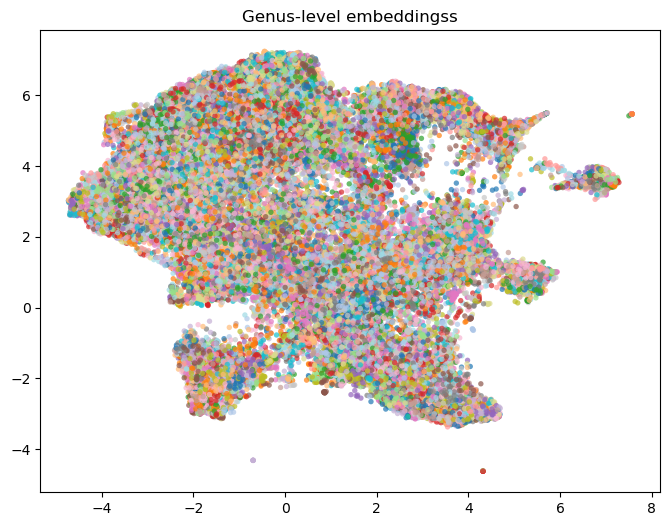

C:\Users\mlasz\anaconda3\envs\biotrove\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


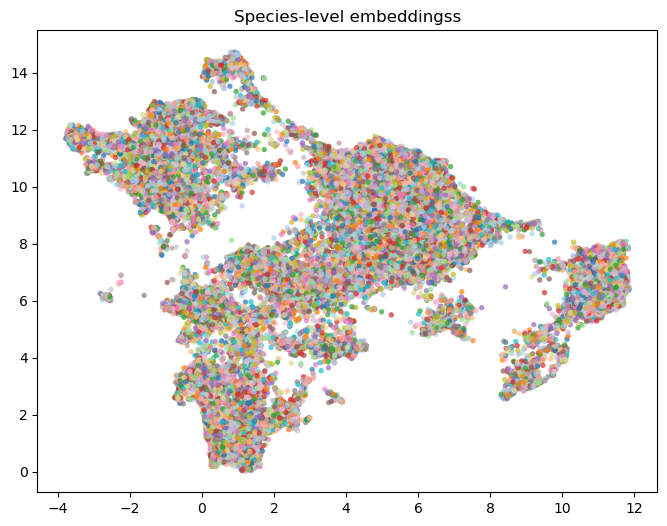

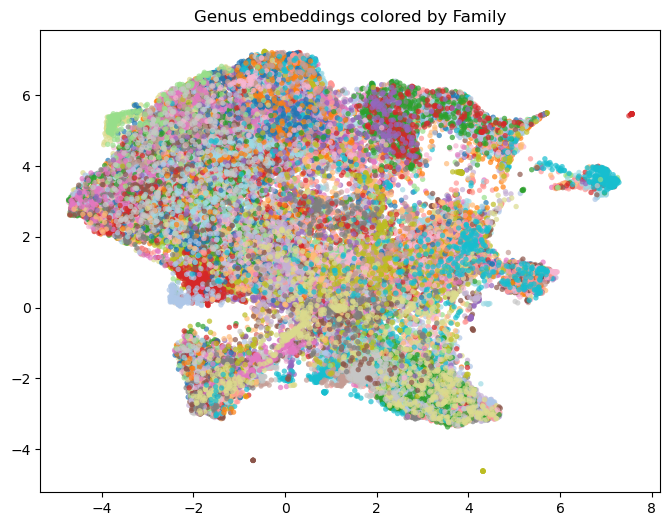

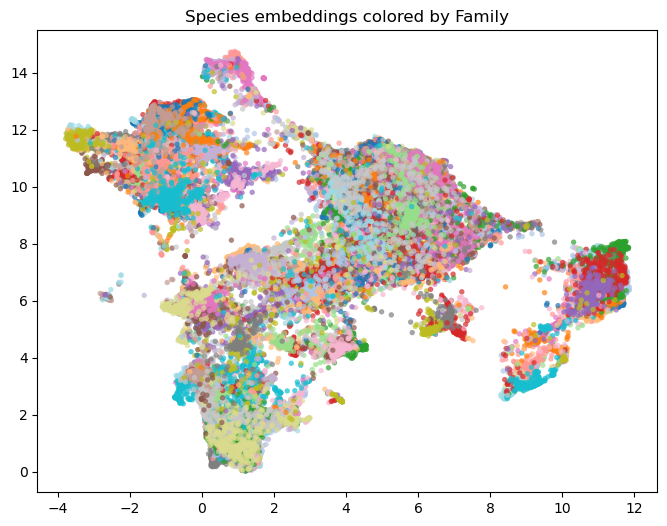

In [17]:
# Reduce to 2D for plotting
umap_2d = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.1, random_state=seed)
genus_2d = umap_2d.fit_transform(genus_embeds)
species_2d = umap_2d.fit_transform(species_embeds)

# Plot function
def plot_umap(coords, labels, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=labels, s=15, linewidth=0, alpha=0.7, palette="tab20")
    plt.title(title)
    plt.legend([],[], frameon=False)
    plt.show()

# Visualize genus clusters
plot_umap(genus_2d, genus_labels, "Genus-level embeddingss")

# Visualize species clusters
plot_umap(species_2d, species_labels, "Species-level embeddingss")

# Optionally color by family
plot_umap(genus_2d, df_result['family_cluster'], "Genus embeddings colored by Family")
plot_umap(species_2d, df_result['family_cluster'], "Species embeddings colored by Family")